# 03 - Feature Engineering: Bank Marketing Dataset

## Bước 4 trong khung 8 bước: Tạo đặc trưng

Gom nhóm (bucket) `age`/`duration`, mã hóa có thứ tự (`poutcome`).

**Input:** kế thừa từ `clean_data()` trong `02_Preprocessing`

**Output:** `data/processed/bank_final.csv` (dùng để train ở `04_Modeling`)

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import load_data, clean_data, raw_path, encode_onehot, categorical_cols, raw_path

%matplotlib inline
sns.set_style('whitegrid')

### A. Load dữ liệu đã clean

In [2]:
raw = load_data(raw_path)
clean_df, _ = clean_data(raw)
clean_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


### B. Gom nhóm AGE thành bucket

In [3]:
# Tính các phân vị
q1 = clean_df['age'].quantile(0.25)
q2 = clean_df['age'].quantile(0.50)
q3 = clean_df['age'].quantile(0.75)

# Tính IQR
iqr = q3 - q1

# Tính ngưỡng ngoại lệ
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# In kết quả
print(f"q1 (25%): {q1}")
print(f"q2 (Median): {q2}")
print(f"q3 (75%): {q3}")
print(f"iqr = q3 - q1 = {iqr}")
print(f"Upper Fence = {upper}")

q1 (25%): 32.0
q2 (Median): 38.0
q3 (75%): 47.0
iqr = q3 - q1 = 15.0
Upper Fence = 69.5


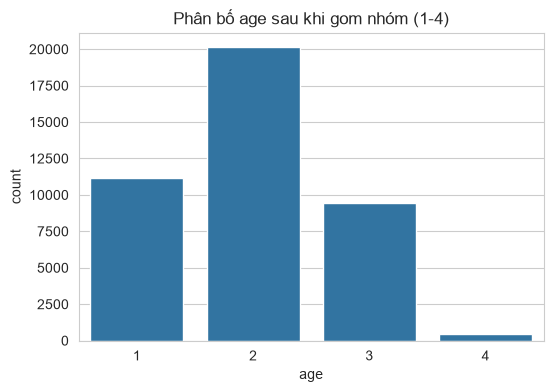

In [4]:
def age_group(dataframe):
    dataframe.loc[dataframe['age'] <= 32, 'age'] = 1
    dataframe.loc[(dataframe['age'] > 32) & (dataframe['age'] <= 47), 'age'] = 2
    dataframe.loc[(dataframe['age'] > 47) & (dataframe['age'] <= 70), 'age'] = 3
    dataframe.loc[(dataframe['age'] > 70) & (dataframe['age'] <= 98), 'age'] = 4
    return dataframe

fe_df = age_group(clean_df.copy())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='age', data=fe_df, ax=ax)
ax.set_title('Phân bố age sau khi gom nhóm (1-4)')
plt.show()

### C. Gom nhóm DURATION thành bucket

In [5]:
# Tính các phân vị
q1 = clean_df['duration'].quantile(0.25)
q2 = clean_df['duration'].quantile(0.50)
q3 = clean_df['duration'].quantile(0.75)

# Tính IQR
iqr = q3 - q1

# Tính ngưỡng ngoại lệ
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# In kết quả
print(f"q1 (25%): {q1}")
print(f"q2 (Median): {q2}")
print(f"q3 (75%): {q3}")
print(f"iqr = q3 - q1 = {iqr}")
print(f"Upper Fence = {upper}")

q1 (25%): 102.0
q2 (Median): 180.0
q3 (75%): 319.0
iqr = q3 - q1 = 217.0
Upper Fence = 644.5


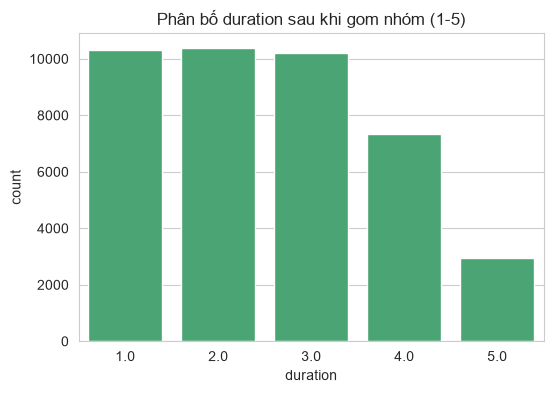

In [6]:
def duration_group(data):
    data.loc[data['duration'] <= 102, 'duration'] = 1
    data.loc[(data['duration'] > 102) & (data['duration'] <= 180), 'duration'] = 2
    data.loc[(data['duration'] > 180) & (data['duration'] <= 319), 'duration'] = 3
    data.loc[(data['duration'] > 319) & (data['duration'] <= 644.5), 'duration'] = 4
    data.loc[data['duration'] > 644.5, 'duration'] = 5
    return data

fe_df = duration_group(fe_df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='duration', data=fe_df, color='mediumseagreen', ax=ax)
ax.set_title('Phân bố duration sau khi gom nhóm (1-5)')
plt.show()

### D. Ordinal Encoding cho poutcome
**Lý do:** `poutcome` có thứ tự ý nghĩa tăng dần (chưa từng liên hệ → thất bại → thành công), nên dùng Ordinal thay vì One-Hot để giữ lại thông tin thứ tự này.

In [7]:
fe_df['poutcome'] = fe_df['poutcome'].replace(
    ['nonexistent', 'failure', 'success'], [1, 2, 3]
)
fe_df['poutcome'].value_counts()

poutcome
1    35547
2     4252
3     1373
Name: count, dtype: int64

### E. Kiểm tra tương quan đặc trưng mới với biến mục tiêu

Dùng để biện minh các đặc trưng vừa tạo có ý nghĩa dự đoán (yêu cầu rubric:
"giải thích lý do bằng tương quan/mutual information").

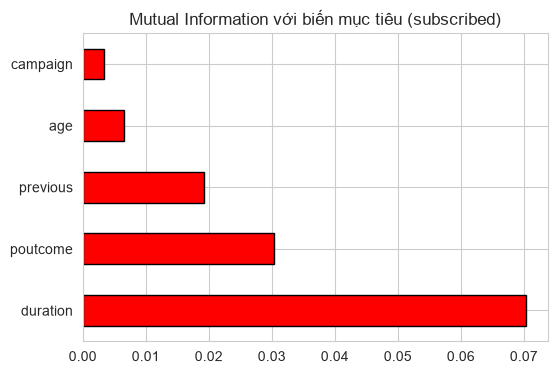

duration    0.070270
poutcome    0.030391
previous    0.019272
age         0.006524
campaign    0.003333
dtype: float64


In [8]:
from sklearn.feature_selection import mutual_info_classif

y_temp = fe_df['subscribed']
X_temp = fe_df[['age', 'duration', 'poutcome', 'campaign', 'previous']]

mi_scores = mutual_info_classif(X_temp, y_temp, discrete_features=True, random_state=42)
mi_df = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
mi_df.plot(kind='barh', ax=ax, color='red', edgecolor="k")
ax.set_title('Mutual Information với biến mục tiêu (subscribed)')
plt.show()

print(mi_df)

**Nhận xét:** `duration` có mutual information cao nhất — hợp lý vì cuộc gọi dài thường đi kèm khách hàng quan tâm hơn
Cột rủi ro: 
Nếu bài toán là dự đoán *trước* khi gọi thì đây là dữ liệu ko có giá trị (chỉ xác định được sau khi triển khai kế hoạch)

In [9]:
remaining_cat_cols = [c for c in categorical_cols if c != 'poutcome']  # poutcome đã ordinal riêng
fe_df = encode_onehot(fe_df, remaining_cat_cols)

fe_df.to_csv('../data/processed/bank_final.csv', index=False, encoding='utf-8')
print(f'Đã lưu {len(fe_df)} dòng, {fe_df.shape[1]} cột vào data/processed/bank_final.csv')

Đã lưu 41172 dòng, 53 cột vào data/processed/bank_final.csv
